# Data Understanding — Near-Earth Objects (NEO)

Este notebook faz a exploração de dados (EDA) do dataset `neo.csv`, no âmbito da fase de **Data Understanding** do processo CRISP-DM.

**Objetivo do negócio:** prever se um objeto próximo da Terra (NEO) é potencialmente perigoso, com base nas suas características físicas e orbitais.

**Estrutura do notebook:**
1. Carregar os dados
2. Visão geral do dataset
3. Qualidade dos dados (valores em falta, duplicados)
4. Estatísticas descritivas
5. Colunas constantes / sem valor preditivo
6. Distribuição da variável-alvo
7. Distribuição das variáveis numéricas
8. Deteção de outliers
9. Comparação por classe
10. Matriz de correlação
11. Resumo dos insights

## 1. Carregar os dados

Se estiveres a correr no Google Colab, corre a célula seguinte para fazeres upload do ficheiro `neo.csv` a partir do teu computador. Se já tiveres o ficheiro no Google Drive, podes montar o Drive em alternativa.

In [ ]:
# Descomenta as linhas seguintes se precisares de fazer upload do ficheiro no Colab
# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("neo.csv")
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


## 2. Visão geral do dataset

In [2]:
print("Dimensões (linhas, colunas):", df.shape)
print("\nTipos de dados:")
print(df.dtypes)
print("\nInformação geral:")
df.info()

Dimensões (linhas, colunas): (90836, 10)

Tipos de dados:
id                      int64
name                   object
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
orbiting_body          object
sentry_object            bool
absolute_magnitude    float64
hazardous                bool
dtype: object

Informação geral:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absol

## 3. Qualidade dos dados

### 3.1 Valores em falta

In [3]:
print("Valores em falta por coluna:")
print(df.isnull().sum())

print("\nPercentagem de valores em falta:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valores em falta por coluna:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

Percentagem de valores em falta:
id                    0.0
name                  0.0
est_diameter_min      0.0
est_diameter_max      0.0
relative_velocity     0.0
miss_distance         0.0
orbiting_body         0.0
sentry_object         0.0
absolute_magnitude    0.0
hazardous             0.0
dtype: float64


### 3.2 Registos duplicados

In [4]:
print("Linhas totalmente duplicadas:", df.duplicated().sum())
print("IDs duplicados:", df['id'].duplicated().sum())

Linhas totalmente duplicadas: 0
IDs duplicados: 63413


## 4. Estatísticas descritivas (variáveis numéricas)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,90836.0,1.438288e+07,2.087202e+07,2.000433e+06,3.448110e+06,3.748362e+06,3.884023e+06,5.427591e+07
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,6.089126e-04,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,1.361570e-03,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,2.033464e+02,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6.745533e+03,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000e+00,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01


## 5. Colunas constantes / sem valor preditivo

Colunas como `orbiting_body` e `sentry_object` podem não variar no dataset, o que as torna irrelevantes para o modelo.

In [6]:
for col in ['orbiting_body', 'sentry_object']:
    print(f"{col}: valores únicos = {df[col].unique()}")

orbiting_body: valores únicos = ['Earth']
sentry_object: valores únicos = [False]


## 6. Distribuição da variável-alvo (`hazardous`)

Esta é a variável que o modelo vai prever. É importante perceber desde já se as classes estão equilibradas, pois isso condiciona as métricas de avaliação a usar mais tarde (ex: accuracy pode ser enganadora em datasets desequilibrados).

hazardous
False    81996
True      8840
Name: count, dtype: int64

Percentagem:
hazardous
False    90.27
True      9.73
Name: proportion, dtype: float64


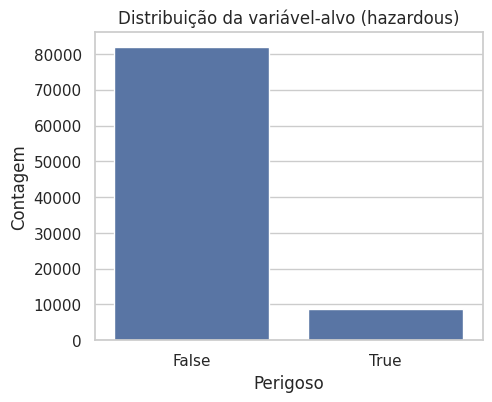

In [7]:
print(df['hazardous'].value_counts())
print("\nPercentagem:")
print((df['hazardous'].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='hazardous')
plt.title("Distribuição da variável-alvo (hazardous)")
plt.xlabel("Perigoso")
plt.ylabel("Contagem")
plt.show()

## 7. Distribuição das variáveis numéricas

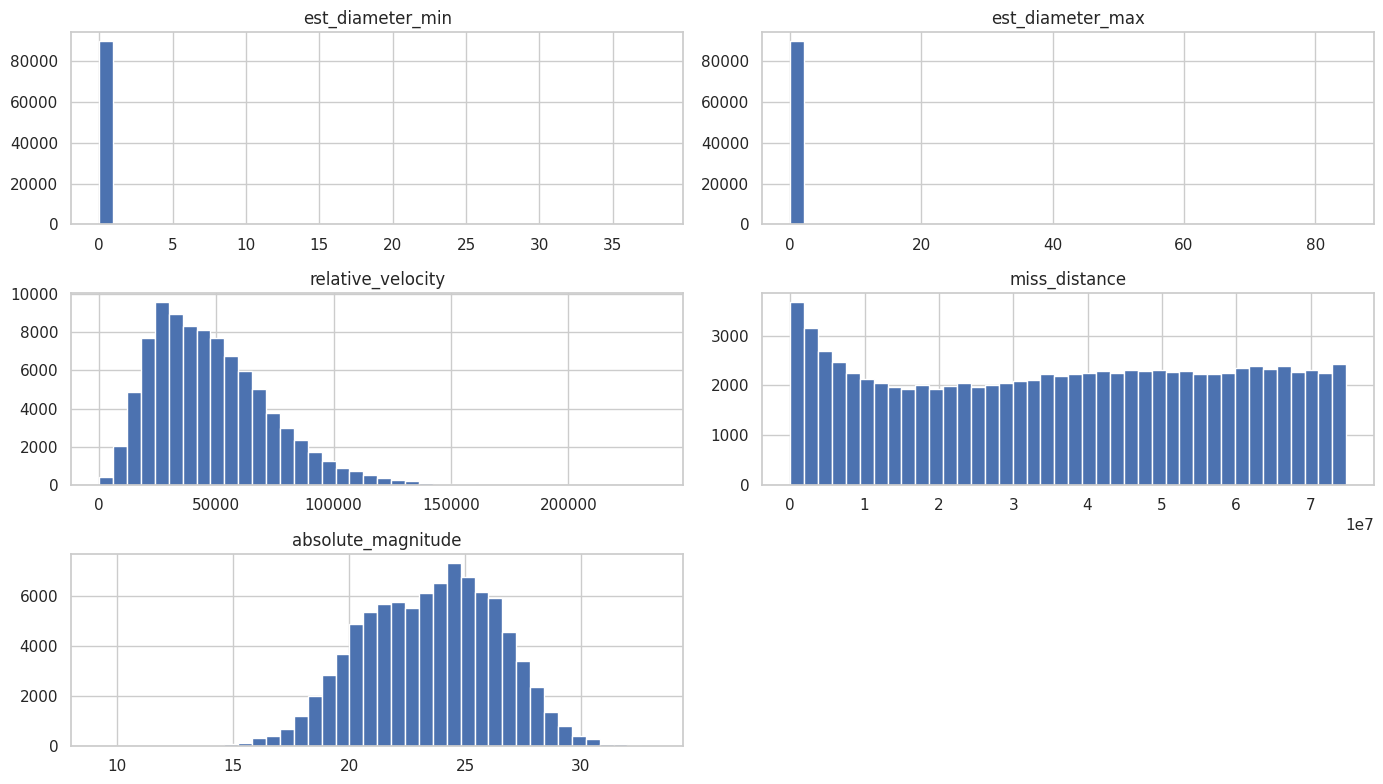

In [8]:
num_cols = ['est_diameter_min', 'est_diameter_max', 'relative_velocity',
            'miss_distance', 'absolute_magnitude']

df[num_cols].hist(bins=40, figsize=(14, 8))
plt.tight_layout()
plt.show()

## 8. Deteção de outliers (boxplots)

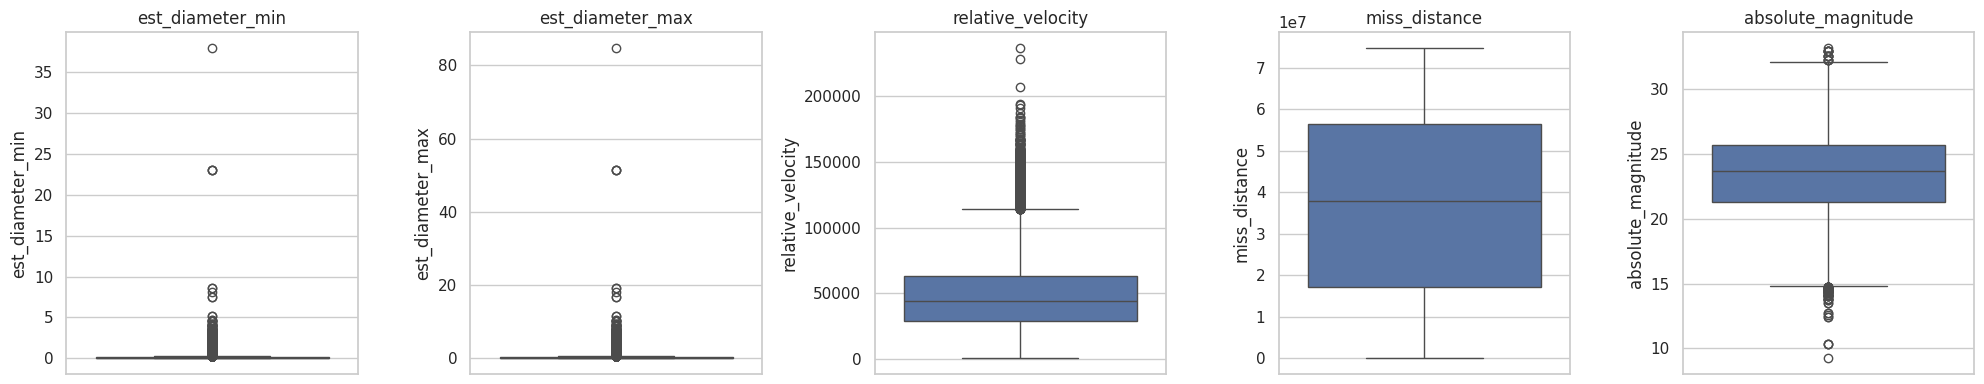

In [9]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 9. Comparação das variáveis por classe (`hazardous`)

Permite perceber visualmente se alguma variável separa bem as duas classes.

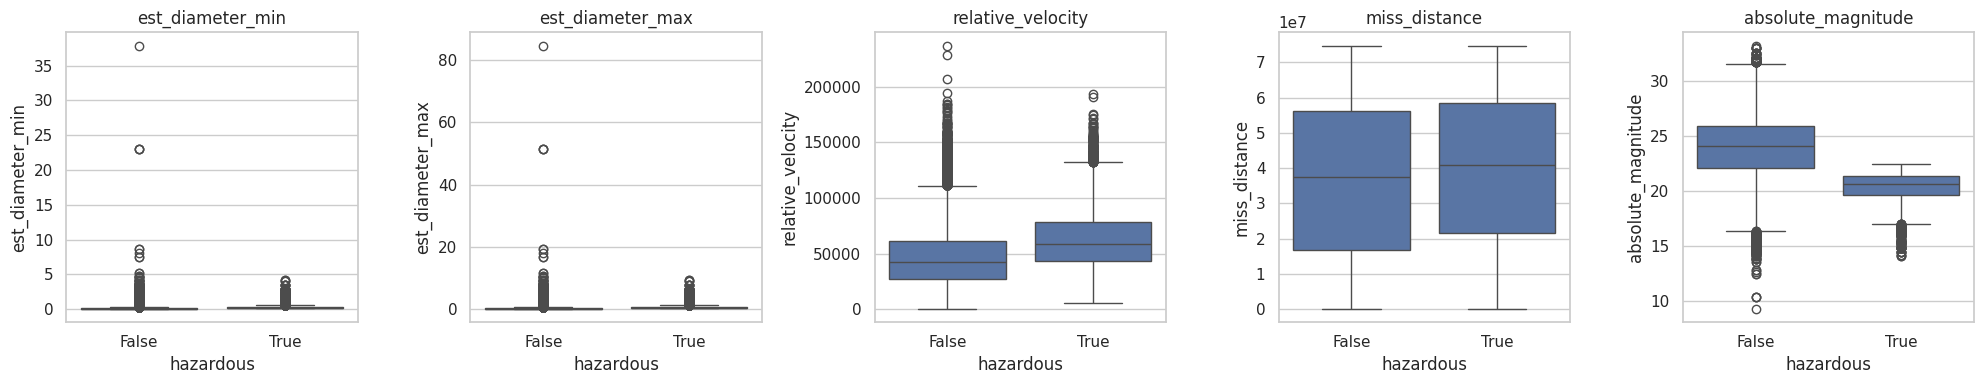

In [10]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='hazardous', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 10. Matriz de correlação

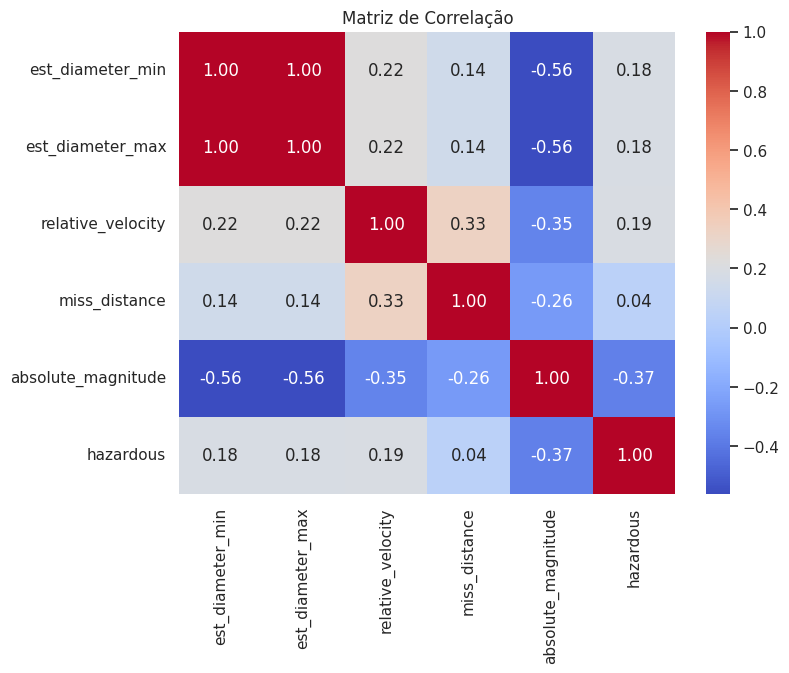

In [11]:
plt.figure(figsize=(8, 6))
corr_df = df[num_cols + ['hazardous']].copy()
corr_df['hazardous'] = corr_df['hazardous'].astype(int)
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

## 11. Resumo dos insights

In [12]:
print("RESUMO DO DATA UNDERSTANDING")
print("-" * 40)
print(f"Total de registos: {len(df)}")
print(f"Total de colunas: {df.shape[1]}")
print(f"Valores em falta: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"Proporção de perigosos (True): {df['hazardous'].mean()*100:.2f}%")
print(f"orbiting_body é constante? {df['orbiting_body'].nunique() == 1}")
print(f"sentry_object é constante? {df['sentry_object'].nunique() == 1}")

RESUMO DO DATA UNDERSTANDING
----------------------------------------
Total de registos: 90836
Total de colunas: 10
Valores em falta: 0
Linhas duplicadas: 0
Proporção de perigosos (True): 9.73%
orbiting_body é constante? True
sentry_object é constante? True


## Conclusões (a preencher)

- O dataset tem **90.836 registos** e **10 colunas**, sem valores em falta.
- A variável-alvo `hazardous` está **desequilibrada** (~90% não perigosos vs. ~10% perigosos) — a considerar na fase de modelação.
- As colunas `orbiting_body` e `sentry_object` são **constantes** neste dataset e não têm valor preditivo — candidatas a remoção na fase de *Data Preparation*.
- As colunas `id` e `name` são identificadores e não devem ser usadas como *features*.
- _(completar com as observações tiradas dos gráficos: quais variáveis parecem separar melhor as classes, se há correlações fortes entre `est_diameter_min` e `est_diameter_max`, outliers relevantes, etc.)_